## Notebook dedicado ao modelo e treinamento.

In [12]:
## Carregando modelo gerado com os dados sintéticos (Incluindo ofertas).
import pandas as pd

df = pd.read_csv('../synthetic_enrichment/offer_events.csv')
df_offers = pd.read_csv('../synthetic_enrichment/offer_catalog.csv')

# ==========================================
# 0. AUMENTANDO A BASE DE DADOS PARA SIMULAR UMA CAMPANHA MAIS LONGA
# ==========================================
# Percebi que mesmo com contexto, o modelo não consegue aprender muito bem com a base original, então decidi multiplicar a base para simular uma campanha mais longa.

# Multiplica a base para simular uma campanha mais longa (dá tempo pro modelo aprender)
df = pd.concat([df]*6).reset_index(drop=True)

# Converte a coluna y de strings Y/N para 1/0, isso vai permitir que o modelo funcione corretamente com a variável de resposta.
if df['y'].dtype == 'object':
   df['y'] = df['y'].astype(str).str.strip().str.upper().map({'YES': 1, 'NO': 0})

# Mapeia o canal a partir do offer_id presente em df_offers
channel_map = df_offers.set_index('offer_id')['channel'].to_dict()
category_map = df_offers.set_index('offer_id')['category'].to_dict()
df['channel'] = df['offer_id'].map(channel_map)
df['category'] = df['offer_id'].map(category_map)
df = df.drop(['offer_id'], axis=1)

# Embaralha os dados e reseta o índice para simular clientes chegando aleatoriamente
# Notei que a ordem dos dados no CSV é sequencial, então embaralhar é importante para simular a chegada de clientes de forma aleatória.
# Notei isso atravéz da repetição de uma curva descendente de conversão, que não é realista.
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.info()
df.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247128 entries, 0 to 247127
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   age             247128 non-null  int64  
 1   job             247128 non-null  int64  
 2   marital         247128 non-null  int64  
 3   education       247128 non-null  int64  
 4   default         247128 non-null  int64  
 5   housing         247128 non-null  int64  
 6   loan            247128 non-null  int64  
 7   month           247128 non-null  object 
 8   day_of_week     247128 non-null  object 
 9   emp.var.rate    247128 non-null  float64
 10  cons.price.idx  247128 non-null  float64
 11  cons.conf.idx   247128 non-null  float64
 12  euribor3m       247128 non-null  float64
 13  nr.employed     247128 non-null  float64
 14  y               247128 non-null  int64  
 15  cluster         247128 non-null  int64  
 16  channel         247128 non-null  object 
 17  category  

,age,job,marital,education,default,housing,loan,month,day_of_week,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,cluster,channel,category
0,38,7,1,3,0,2,0,may,tue,1.1,93.994,-36.4,4.857,5191.0,0,4,App Push,Investimento
1,25,7,1,5,1,0,0,may,thu,1.1,93.994,-36.4,4.855,5191.0,0,4,App Push,Serviços
2,51,0,1,3,1,0,0,may,fri,-1.8,92.893,-46.2,1.313,5099.1,0,3,SMS,Serviços
3,59,0,1,5,0,0,0,may,mon,1.1,93.994,-36.4,4.857,5191.0,0,2,Banner,Crédito
4,39,9,0,5,1,2,0,aug,tue,1.4,93.444,-36.1,4.965,5228.1,0,4,Email,Investimento
5,36,6,1,6,0,2,0,may,mon,-1.8,92.893,-46.2,1.264,5099.1,0,4,Banner,Crédito
6,33,1,1,5,0,2,0,may,fri,1.1,93.994,-36.4,4.859,5191.0,0,2,Email,Investimento
7,56,10,0,0,0,0,2,oct,fri,-1.1,94.601,-49.5,0.972,4963.6,1,3,Email,Crédito
8,46,2,2,5,0,2,0,nov,thu,-0.1,93.200,-42.0,3.879,5195.8,0,5,Email,Investimento
9,32,7,1,3,0,0,0,oct,mon,-3.4,92.431,-26.9,0.739,5017.5,0,4,App Push,Crédito


In [13]:
## 1. Calcula a taxa de conversão média para cada oferta
# verifica se offer_id existe no DataFrame antes de calcular a taxa de conversão
if 'offer_id' in df.columns:
    conversion_rates = df.groupby('offer_id')['y'].mean().reset_index()
    conversion_rates = conversion_rates.rename(columns={'y': 'conversion_rate'})

    # 2. Descobre qual é a melhor oferta global (Melhor Histórico)
    best_offer = conversion_rates.sort_values(by='conversion_rate', ascending=False).iloc[0]

    baseline_offer_id = best_offer['offer_id']
    baseline_expected_conversion = best_offer['conversion_rate']

    print(f"O Baseline determinístico será oferecer sempre: {baseline_offer_id}")
    print(f"Taxa de conversão esperada dessa regra fixa: {baseline_expected_conversion:.4f}")

    print(best_offer['offer_id'])

    print(conversion_rates.sort_values(by='conversion_rate', ascending=False).head(5))

### Vou testar separando em categorias de ofertas, para ver se o modelo consegue aprender melhor.

## 1. Calcula a taxa de conversão média para cada oferta
conversion_rates = df.groupby('category')['y'].mean().reset_index()
conversion_rates = conversion_rates.rename(columns={'y': 'conversion_rate'})

# 2. Descobre qual é a melhor oferta global (Melhor Histórico)
best_offer = conversion_rates.sort_values(by='conversion_rate', ascending=False).iloc[0]

baseline_offer_id = best_offer['category']
baseline_expected_conversion = best_offer['conversion_rate']

print(f"O Baseline determinístico será oferecer sempre: {baseline_offer_id}")
print(f"Taxa de conversão esperada dessa regra fixa: {baseline_expected_conversion:.4f}")

print(best_offer)

conversion_rates.sort_values(by='conversion_rate', ascending=False).head(10)


O Baseline determinístico será oferecer sempre: Investimento
Taxa de conversão esperada dessa regra fixa: 0.1178
category           Investimento
conversion_rate        0.117834
Name: 1, dtype: object


,category,conversion_rate
1,Investimento,0.117834
0,Crédito,0.114200
3,Serviços,0.110402
2,Seguros,0.106759


## Carregando e salvando o modelo.

Notei que cada execução como partia sempre do alpha e beta = 1 os dados iniciais era bem baixos e nunca iriam ultrapassar o baseline sem um pouco de sorte.

Por isso criei funções para "continuar" treinando o cérebro do modelo depois de ter achado um bom equilibrio.

In [14]:
import json
import os

def carregar_modelo(arquivo, ofertas):
    """Carrega o modelo do disco se existir, senão inicializa do zero."""
    if os.path.exists(arquivo):
        print("🧠 Arquivo encontrado! Carregando aprendizado anterior...")
        with open(arquivo, 'r') as f:
            return json.load(f)
    else:
        print("🌱 Arquivo não encontrado. Inicializando modelo do zero (Priors = 1)...")
        return {
            'alphas': {offer: 1 for offer in ofertas},
            'betas': {offer: 1 for offer in ofertas},
            'iteracoes': 0,
        }

def carregar_modelo_contextual(arquivo, segmentos, ofertas):
    """Carrega o modelo do disco se existir, senão inicializa do zero."""
    if os.path.exists(arquivo):
        print("🧠 Arquivo encontrado! Carregando aprendizado anterior...")
        with open(arquivo, 'r') as f:
            return json.load(f)
    else:
        print("🌱 Arquivo não encontrado. Inicializando modelo do zero (Priors = 1)...")
        return {
            **{
                segmento: {
                    'alphas': {offer: 1 for offer in ofertas},
                    'betas': {offer: 1 for offer in ofertas}
                }
                for segmento in segmentos
            },
            'iteracoes': 0
        }

def salvar_modelo(modelo, arquivo):
    """Salva o estado atual das distribuições no disco."""
    with open(arquivo, 'w') as f:
        json.dump(modelo, f, indent=4)
    print("💾 Estado do modelo salvo com sucesso!")

## Depois do baseline, "rodando" o thompson sampling SEM CONTEXTO.

Total de ofertas unicas: 4
🌱 Arquivo não encontrado. Inicializando modelo do zero (Priors = 1)...
--- RESULTADOS DO THOMPSON SAMPLING ---
Recompensas obtidas (Cliques/Conversões): 7489
Interações válidas (Matches no Replay): 64441
Taxa de conversão do Modelo Adaptativo: 11.62%

--- COMPARAÇÃO QUANTITATIVA ---
Taxa de conversão do Baseline: 11.78%
Taxa de conversão do Thompson Sampling: 11.62%
Uplift do Thompson Sampling sobre o Baseline: -1.37%


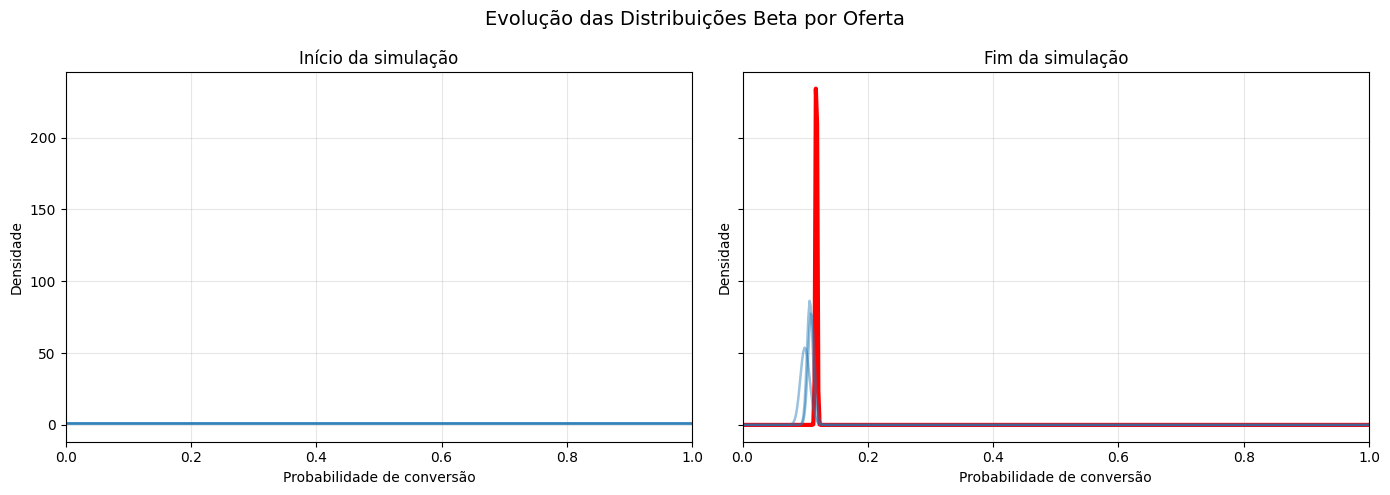

💾 Estado do modelo salvo com sucesso!


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import lgamma

# ==========================================
# ALGORITMO ADAPTATIVO: Thompson Sampling
# ==========================================
# Exploração bayesiana sob incerteza para modelar conversão.
# TODO: Procurar se em alguma aula do curso isso já foi abordado.
# "Priors documentados" (Documented Priors) e se há alguma referência bibliográfica que possamos citar.

#offers = df['offer_id'].unique()
offers = df['category'].unique()

print(f"Total de ofertas unicas: {len(offers)}")

# Definindo os "Priors documentados" 
# Iniciamos alpha (sucessos) e beta (fracassos) com 1 para todas as ofertas (Distribuição Uniforme)
modelos_ts = carregar_modelo('thompson_sampling_model.json', offers)
alphas = dict(modelos_ts['alphas'])
betas = dict(modelos_ts['betas'])

ts_matches = 0
ts_rewards = 0

# Fator de decaimento: 99% (esquece 1% do peso histórico a cada iteração)
# Depois que eu implementei o salvamento do estado do modelo, percebi que o decaimento é necessário.
DECAY_FACTOR = 1

# Iterando sobre o DataFrame (simulando a chegada de clientes no tempo)
for index, row in df.iterrows():
    #historical_offer = row['offer_id']
    historical_offer = row['category']
    historical_reward = row['y']
    
    # 2.0 O Algoritmo toma a decisão (Amostragem da Distribuição Beta)
    # Toda essa parte do "Thompson Sampling" veio de pesquisas externas sobre o algoritmo, e é uma implementação padrão do mesmo.
    sampled_theta = {
        offer: np.random.beta(alphas[offer], betas[offer]) 
        for offer in offers
    }
    chosen_offer = max(sampled_theta, key=sampled_theta.get)
    
    # 2.1 Avaliação Offline (Replay)
    # Só aprendemos se o algoritmo escolheu a MESMA oferta que o cliente realmente viu
    if chosen_offer == historical_offer:
        ts_matches += 1
        ts_rewards += historical_reward
        
        # Atualização Bayesiana
        if historical_reward == 1:
            alphas[chosen_offer] += 1
            alphas[chosen_offer] = max(1, alphas[chosen_offer] * DECAY_FACTOR)  # Sucesso
        else:
            betas[chosen_offer] += 1
            betas[chosen_offer] = max(1, betas[chosen_offer] * DECAY_FACTOR)  # Fracasso

# Calculando as métricas de recompensa e conversão simulada reportadas 
ts_conversion_rate = ts_rewards / ts_matches if ts_matches > 0 else 0

print("--- RESULTADOS DO THOMPSON SAMPLING ---")
print(f"Recompensas obtidas (Cliques/Conversões): {ts_rewards}")
print(f"Interações válidas (Matches no Replay): {ts_matches}")
print(f"Taxa de conversão do Modelo Adaptativo: {ts_conversion_rate:.2%}\n")

# ==========================================
# 3. COMPARAÇÃO DE GANHO (Evidência Esperada)
# ==========================================
uplift = (ts_conversion_rate - baseline_expected_conversion) / baseline_expected_conversion
print("--- COMPARAÇÃO QUANTITATIVA ---")
print(f"Taxa de conversão do Baseline: {baseline_expected_conversion:.2%}")
print(f"Taxa de conversão do Thompson Sampling: {ts_conversion_rate:.2%}")
print(f"Uplift do Thompson Sampling sobre o Baseline: {uplift:+.2%}")

# ==========================================
# 4. GRÁFICO DE EVOLUÇÃO DAS DISTRIBUIÇÕES BETA
# ==========================================
def beta_pdf(x, alpha, beta):
    if alpha <= 0 or beta <= 0:
        return np.zeros_like(x, dtype=float)
    log_norm = lgamma(alpha + beta) - lgamma(alpha) - lgamma(beta)
    return np.exp((alpha - 1) * np.log(x) + (beta - 1) * np.log(1 - x) + log_norm)

x = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, title, alpha_dict, beta_dict in [
    (axes[0], "Início da simulação", modelos_ts['alphas'], modelos_ts['betas']),
    (axes[1], "Fim da simulação", alphas, betas),
]:
    champion_offer = None
    if title == "Fim da simulação":
        champion_offer = max(offers, key=lambda offer: alphas[offer] / (alphas[offer] + betas[offer]))

    for offer in offers:
        y = beta_pdf(x, alpha_dict[offer], beta_dict[offer])
        is_champion = offer == champion_offer
        ax.plot(
            x,
            y,
            lw=3 if is_champion else 1.8,
            color='red' if is_champion else 'tab:blue',
            alpha=1.0 if is_champion else 0.45,
        )

    ax.set_title(title)
    ax.set_xlabel('Probabilidade de conversão')
    ax.set_ylabel('Densidade')
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.3)

fig.suptitle('Evolução das Distribuições Beta por Oferta', fontsize=14)
plt.tight_layout()
plt.show()

# ==========================================
# 5. SALVA O MODELO PARA USOS FUTUROS
# ==========================================
salvar_modelo({'alphas': alphas, 'betas': betas, 'iteracoes': modelos_ts['iteracoes'] + 1}, 'thompson_sampling_model.json')

## Gerando o Thompson agora COM CONTEXTO

Total de segmentos de contexto criados: 172
🧠 Arquivo encontrado! Carregando aprendizado anterior...
--- RESULTADOS DO THOMPSON SAMPLING CONTEXTUAL ---
Interações válidas para aprendizado (Matches): 62746
Taxa de conversão do Modelo Adaptativo: 13.46%

Uplift do TS Contextual sobre o Baseline Global: +14.21%
--- AVALIAÇÃO DE REGRET E UPLIFT REAL ---
1. Taxa do Baseline (Regra Fixa Vidente): 11.78%
2. Bandit na Fase de Exploração (Aprendendo): 13.30% -> Pagando o Custo de Exploração
3. Bandit na Fase de Explotação (Inteligente): 13.61% -> O verdadeiro poder do modelo

Uplift Real do Modelo Treinado sobre o Baseline: +15.53%


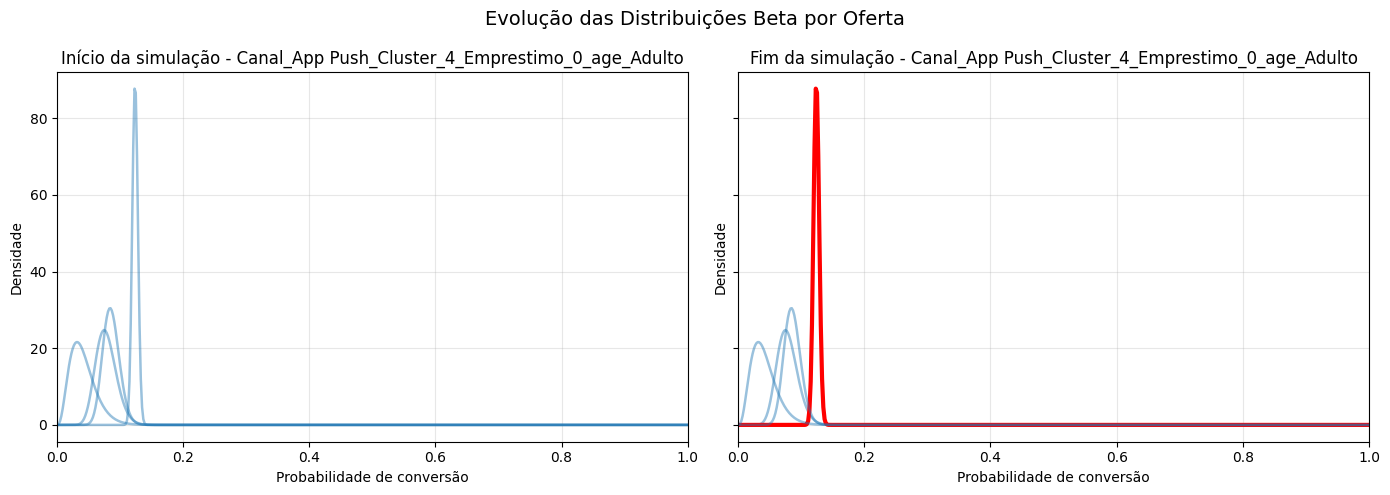

💾 Estado do modelo salvo com sucesso!


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import lgamma

# ==========================================
# 1. CRIANDO A CHAVE DE CONTEXTO
# ==========================================
# Combinamos o Cluster Socioeconômico e o Canal para criar nichos super específicos

# df['context_segment'] = 'Cluster_' + df['cluster'].astype(str) + '_Canal_' + df['channel'].astype(str)
# df['context_segment'] = 'Canal_' + df['channel'].astype(str)
# df['context_segment'] = 'Cluster_' + df['cluster'].astype(str)

# Agrupa a idade em categorias amplas
bins = [0, 30, 55, 120]
labels = ['Jovem', 'Adulto', 'Senior']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
#df['context_segment'] = 'Cluster_' + df['cluster'].astype(str) + '_age_' + df['age_group'].astype(str)

# Criando a chave combinada no DataFrame
# df['context_segment'] = 'Cluster_' + df['cluster'].astype(str) + '_Emprestimo_' + df['loan'].astype(str)

df['context_segment'] = 'Canal_' + df['channel'].astype(str) + '_Cluster_' + df['cluster'].astype(str) + '_Emprestimo_' + df['loan'].astype(str) + '_age_' + df['age_group'].astype(str)

# Exemplo de resultado: "Cluster_2_Emprestimo_no"

segmentos_unicos = df['context_segment'].unique()
# Assumindo que a coluna do produto/oferta que o cliente recebeu se chama 'offer_id'
#ofertas_disponiveis = df['offer_id'].unique() 
ofertas_disponiveis = df['category'].unique()

print(f"Total de segmentos de contexto criados: {len(segmentos_unicos)}")

# ==========================================
# 2. THOMPSON SAMPLING CONTEXTUAL
# ==========================================
# Criamos um dicionário de modelos: Um Bandit independente para cada combinação de Cluster + Canal
modelos_ts = carregar_modelo_contextual('thompson_sampling_contextual_model.json', segmentos_unicos, ofertas_disponiveis)

ts_matches = 0
ts_rewards = 0

# Fator de decaimento: 99% (esquece 1% do peso histórico a cada iteração)
# Depois que eu implementei o salvamento do estado do modelo, percebi que o decaimento é necessário.
DECAY_FACTOR = 1

historico_recompensas = []

# Avaliação Offline (Replay Method)
for index, row in df.iterrows():
    segmento_atual = row['context_segment']
    #historical_offer = row['offer_id']
    historical_offer = row['category']  # Usando a categoria como oferta para o modelo contextual
    historical_reward = row['y']
    
    # 3.1. Recuperar o modelo específico daquele segmento (Ex: Cluster_0_Canal_email)
    alphas_segmento = modelos_ts[segmento_atual]['alphas']
    betas_segmento = modelos_ts[segmento_atual]['betas']
    
    # 3.2. O Algoritmo amostra as probabilidades (Distribuição Beta)
    sampled_theta = {
        offer: np.random.beta(alphas_segmento[offer], betas_segmento[offer]) 
        for offer in ofertas_disponiveis
    }
    # Escolhe a oferta com o maior valor sorteado
    chosen_offer = max(sampled_theta, key=sampled_theta.get)
    
    # 3.3. Aprendizado: Só atualiza se a escolha bateu com o que ocorreu no passado
    if chosen_offer == historical_offer:
        ts_matches += 1
        ts_rewards += historical_reward
        historico_recompensas.append(historical_reward)
        
        # Atualização Bayesiana APENAS no modelo daquele segmento específico
        if historical_reward == 1:
            modelos_ts[segmento_atual]['alphas'][chosen_offer] += 1
            modelos_ts[segmento_atual]['alphas'][chosen_offer] = max(1, modelos_ts[segmento_atual]['alphas'][chosen_offer] * DECAY_FACTOR)  # Sucesso
        else:
            modelos_ts[segmento_atual]['betas'][chosen_offer] += 1
            modelos_ts[segmento_atual]['betas'][chosen_offer] = max(1, modelos_ts[segmento_atual]['betas'][chosen_offer] * DECAY_FACTOR)  # Sucesso

ts_conversion_rate = ts_rewards / ts_matches if ts_matches > 0 else 0

print("--- RESULTADOS DO THOMPSON SAMPLING CONTEXTUAL ---")
print(f"Interações válidas para aprendizado (Matches): {ts_matches}")
print(f"Taxa de conversão do Modelo Adaptativo: {ts_conversion_rate:.2%}")

# ==========================================
# 3. COMPARAÇÃO DE GANHO (Evidência Esperada)
# ==========================================

# Compara desde o começo da simulação, mesmo quando o modelo ainda estava aprendendo, com o Baseline Global (Melhor Oferta Histórica)
uplift = (ts_conversion_rate - baseline_expected_conversion) / baseline_expected_conversion
print(f"\nUplift do TS Contextual sobre o Baseline Global: {uplift:+.2%}")

# Vamos dividir a história do modelo em duas metades
meio_do_caminho = len(historico_recompensas) // 2

# Primeira metade: O modelo estava cego, errando muito para aprender
fase_exploracao = historico_recompensas[:meio_do_caminho]
taxa_exploracao = sum(fase_exploracao) / len(fase_exploracao)

# Segunda metade: O modelo já aprendeu e está focado na melhor oferta
fase_explotacao = historico_recompensas[meio_do_caminho:]
taxa_explotacao = sum(fase_explotacao) / len(fase_explotacao)

print("--- AVALIAÇÃO DE REGRET E UPLIFT REAL ---")
print(f"1. Taxa do Baseline (Regra Fixa Vidente): {baseline_expected_conversion:.2%}")
print(f"2. Bandit na Fase de Exploração (Aprendendo): {taxa_exploracao:.2%} -> Pagando o Custo de Exploração")
print(f"3. Bandit na Fase de Explotação (Inteligente): {taxa_explotacao:.2%} -> O verdadeiro poder do modelo")

# Calcula o Uplift Justo (Modelo treinado vs Baseline estático)
uplift_real = (taxa_explotacao - baseline_expected_conversion) / baseline_expected_conversion
print(f"\nUplift Real do Modelo Treinado sobre o Baseline: {uplift_real:+.2%}")

# ==========================================
# 4. GRÁFICO DE EVOLUÇÃO DAS DISTRIBUIÇÕES BETA
# ==========================================
def beta_pdf(x, alpha, beta):
    if alpha <= 0 or beta <= 0:
        return np.zeros_like(x, dtype=float)
    log_norm = lgamma(alpha + beta) - lgamma(alpha) - lgamma(beta)
    return np.exp((alpha - 1) * np.log(x) + (beta - 1) * np.log(1 - x) + log_norm)

x = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Usa o primeiro segmento como referência para ilustrar a evolução das distribuições Beta
segmento_ref = next(iter(modelos_ts))
initial_alphas = dict(modelos_ts[segmento_ref]['alphas'])
initial_betas = dict(modelos_ts[segmento_ref]['betas'])

for ax, title, alpha_dict, beta_dict in [
    (axes[0], "Início da simulação", initial_alphas, initial_betas),
    (axes[1], "Fim da simulação", modelos_ts[segmento_ref]['alphas'], modelos_ts[segmento_ref]['betas']),
]:
    champion_offer = None
    if title == "Fim da simulação":
        champion_offer = max(ofertas_disponiveis, key=lambda offer: modelos_ts[segmento_ref]['alphas'][offer] / (modelos_ts[segmento_ref]['alphas'][offer] + modelos_ts[segmento_ref]['betas'][offer]))

    for offer in ofertas_disponiveis:
        y = beta_pdf(x, alpha_dict[offer], beta_dict[offer])
        is_champion = offer == champion_offer
        ax.plot(
            x,
            y,
            lw=3 if is_champion else 1.8,
            color='red' if is_champion else 'tab:blue',
            alpha=1.0 if is_champion else 0.45,
        )

    ax.set_title(title + " - " + segmento_ref)
    ax.set_xlabel('Probabilidade de conversão')
    ax.set_ylabel('Densidade')
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.3)

fig.suptitle('Evolução das Distribuições Beta por Oferta', fontsize=14)
plt.tight_layout()
plt.show()

# ==========================================
# 5. SALVA O MODELO PARA USOS FUTUROS
# ==========================================
modelos_ts['iteracoes'] += 1
salvar_modelo(modelos_ts, 'thompson_sampling_contextual_model.json')

# Coletando dados com o MLFlow.

In [20]:
import mlflow

# 1. Criar ou conectar a um Experimento no MLflow
mlflow.set_experiment("Datathon_Experimentacao_Adaptativa")

# 2. Iniciar a "Rodada" (Run) de registro
with mlflow.start_run(run_name="Thompson_Sampling_Contextual_v1"):
    
    print("Iniciando o rastreamento no MLflow...")

    # 3. Registrar Parâmetros (O "Setup" do experimento)
    mlflow.log_param("tamanho_dataset", len(df))
    mlflow.log_param("algoritmo", "Contextual Thompson Sampling")
    mlflow.log_param("variaveis_contexto", "Cluster + Empréstimo")
    mlflow.log_param("total_segmentos", len(modelos_ts))
    
    # 4. Registrar as Métricas (Os seus resultados de Ouro!)
    mlflow.log_metric("taxa_baseline", baseline_expected_conversion)
    mlflow.log_metric("taxa_exploracao_bandit", taxa_exploracao)
    mlflow.log_metric("taxa_explotacao_bandit", taxa_explotacao)
    mlflow.log_metric("uplift_real", uplift_real)
    
    # 5. Salvar o "Cérebro" do modelo como um Artefato Auditável
    mlflow.log_artifact('thompson_sampling_contextual_model.json')
    
    print("✅ Experimento rastreado e artefato salvo com sucesso no MLflow!")

Iniciando o rastreamento no MLflow...
✅ Experimento rastreado e artefato salvo com sucesso no MLflow!
